# Step 5 — Skill-Gap Analysis (Association Rules)

Computes pairwise associations between skills using classic measures from association rule mining:

- **Support:**  $\text{supp}(A, B) = P(A \cap B)$
- **Confidence:**  $\text{conf}(A \to B) = P(B \mid A) = P(A \cap B) / P(A)$
- **Lift:**  $\text{lift}(A, B) = P(A \cap B) / (P(A) \cdot P(B))$

Skill-gap interpretation: *"if a vacancy requires skill A, then skill B is expected with probability X%"* — useful for advising candidates on which complementary skills to learn.

**Outputs:**
- `skillgap_top_pairs.csv` — top pairs by lift
- `skillgap_recommendations.csv` — top-5 complementary skills for each popular skill
- `skillgap_heatmap.png` — confidence heatmap for top-25 skills

## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from itertools import combinations

INPUT_PATH = 'path/to/step3_vacancies_with_skills.parquet'
OUT_DIR    = '/kaggle/working'

import os
os.makedirs(OUT_DIR, exist_ok=True)

## 2. Load and Filter Data

In [2]:
df = pd.read_parquet(INPUT_PATH)
print(f'Total parents: {len(df):,}')

# Keep only vacancies with at least 2 skills (otherwise no pair possible)
df = df[df['skills'].apply(len) >= 2].reset_index(drop=True).copy()
N = len(df)
print(f'With ≥2 skills: {N:,}')

Total parents: 27,720
With ≥2 skills: 19,472


## 3. Compute Skill Counts and Pair Counts

In [3]:
# Individual skill frequencies
skill_freq = Counter()
for s_list in df['skills']:
    skill_freq.update(s_list)

# Keep only popular skills to bound complexity (popular = present in >= 100 vacancies)
MIN_FREQ = 100
popular = {s for s, c in skill_freq.items() if c >= MIN_FREQ}
print(f'Popular skills (≥{MIN_FREQ} occurrences): {len(popular)}')

# Pair frequencies among popular skills
pair_freq = Counter()
for s_list in df['skills']:
    pop_skills = sorted(set(s_list) & popular)
    for a, b in combinations(pop_skills, 2):
        pair_freq[(a, b)] += 1

print(f'Unique popular pairs observed: {len(pair_freq):,}')

Popular skills (≥100 occurrences): 203
Unique popular pairs observed: 13,964


## 4. Build the Pair Table with Support, Confidence, Lift

In [4]:
rows = []
for (a, b), n_ab in pair_freq.items():
    n_a = skill_freq[a]
    n_b = skill_freq[b]
    supp_ab = n_ab / N
    supp_a  = n_a / N
    supp_b  = n_b / N
    conf_ab = n_ab / n_a   # A -> B
    conf_ba = n_ab / n_b   # B -> A
    lift    = supp_ab / (supp_a * supp_b)
    rows.append({
        'A': a, 'B': b,
        'n_AB': n_ab, 'n_A': n_a, 'n_B': n_b,
        'support_AB': supp_ab,
        'conf_A_to_B': conf_ab,
        'conf_B_to_A': conf_ba,
        'lift': lift,
    })

pairs = pd.DataFrame(rows)
# Drop very rare pairs (support < 0.5%)
MIN_SUPPORT = 0.005
pairs = pairs[pairs['support_AB'] >= MIN_SUPPORT].reset_index(drop=True)
print(f'Pairs after support filter (≥{MIN_SUPPORT*100:.1f}%): {len(pairs):,}')

Pairs after support filter (≥0.5%): 951


## 5. Top Pairs by Lift

These are the most "surprising" associations — pairs that co-occur much more often than independence would predict.

In [5]:
top_pairs = pairs.sort_values('lift', ascending=False).head(20).copy()
top_pairs['support_pct']  = (top_pairs['support_AB'] * 100).round(2)
top_pairs['conf_A_to_B']  = (top_pairs['conf_A_to_B'] * 100).round(1)
top_pairs['conf_B_to_A']  = (top_pairs['conf_B_to_A'] * 100).round(1)
top_pairs['lift']         = top_pairs['lift'].round(2)

display_cols = ['A', 'B', 'n_AB', 'support_pct', 'conf_A_to_B', 'conf_B_to_A', 'lift']
print('Top 20 skill pairs by lift:')
print(top_pairs[display_cols].to_string(index=False))

pairs.sort_values('lift', ascending=False).to_csv(f'{OUT_DIR}/skillgap_top_pairs.csv', index=False)

Top 20 skill pairs by lift:
               A                  B  n_AB  support_pct  conf_A_to_B  conf_B_to_A   lift
             I2C                SPI   140         0.72         92.1         90.9 116.46
             I2C               UART   139         0.71         91.4         86.3 110.60
             SPI               UART   140         0.72         90.9         87.0 109.95
       LangChain         LlamaIndex   111         0.57         26.4         91.0  42.18
             DNS             TCP/IP   108         0.55         45.8         47.4  39.08
       LangChain          LangGraph   123         0.63         29.3         75.9  35.20
             EC2                RDS   123         0.63         47.1         45.2  33.74
         Cypress         Playwright   100         0.51         63.7         25.9  32.13
    Facebook Ads         Google Ads   186         0.96         63.1         46.7  30.85
           NumPy             Pandas   365         1.87         86.1         67.0  30.76
    

## 6. Skill-Gap Recommendations

For each popular skill `A`, list top-5 complementary skills `B` ranked by **confidence** $P(B \mid A)$. Reads as: *"if you list A on your CV, employers expect B with probability X%"*.

In [6]:
# Build directed table: for each A, all B candidates with confidence and lift
directed_rows = []
for _, r in pairs.iterrows():
    directed_rows.append({'from': r['A'], 'to': r['B'], 'confidence': r['conf_A_to_B'], 'lift': r['lift'], 'support': r['support_AB']})
    directed_rows.append({'from': r['B'], 'to': r['A'], 'confidence': r['conf_B_to_A'], 'lift': r['lift'], 'support': r['support_AB']})
directed = pd.DataFrame(directed_rows)

# Filter out trivial self-implications and keep only meaningful associations (lift > 1.2)
directed = directed[directed['lift'] > 1.2].copy()

# For each 'from' skill, top-5 'to' skills by confidence
recommendations = []
for source, grp in directed.groupby('from'):
    top5 = grp.sort_values('confidence', ascending=False).head(5)
    for _, r in top5.iterrows():
        recommendations.append({
            'skill': source,
            'recommended': r['to'],
            'confidence_pct': round(r['confidence'] * 100, 1),
            'lift': round(r['lift'], 2),
        })
recs = pd.DataFrame(recommendations).sort_values(['skill', 'confidence_pct'], ascending=[True, False])
recs.to_csv(f'{OUT_DIR}/skillgap_recommendations.csv', index=False)

print(f'Recommendations: {len(recs):,} rows across {recs["skill"].nunique()} source skills')
print('\nExamples (Python, JavaScript, Docker, AWS, DevOps-related):')
for skill in ['Python', 'JavaScript', 'Docker', 'AWS', 'React']:
    sub = recs[recs['skill'] == skill]
    if not sub.empty:
        print(f'\n→ {skill}:')
        for _, r in sub.iterrows():
            print(f'    {r["recommended"]:<22} confidence = {r["confidence_pct"]:>5.1f}%   lift = {r["lift"]:.2f}')

Recommendations: 551 rows across 148 source skills

Examples (Python, JavaScript, Docker, AWS, DevOps-related):

→ Python:
    AWS                    confidence =  33.2%   lift = 1.55
    Docker                 confidence =  33.0%   lift = 1.50
    Kubernetes             confidence =  27.3%   lift = 1.28
    SQL                    confidence =  27.0%   lift = 1.57
    PostgreSQL             confidence =  25.3%   lift = 1.24

→ JavaScript:
    TypeScript             confidence =  35.8%   lift = 4.23
    React                  confidence =  34.8%   lift = 3.99
    Git                    confidence =  31.4%   lift = 2.23
    HTML                   confidence =  30.3%   lift = 8.43
    CSS                    confidence =  29.8%   lift = 8.65

→ Docker:
    Python                 confidence =  55.6%   lift = 1.50
    Kubernetes             confidence =  55.4%   lift = 2.60
    AWS                    confidence =  46.6%   lift = 2.17
    PostgreSQL             confidence =  39.9%   lift = 1.

## 7. Confidence Heatmap for Top-25 Skills

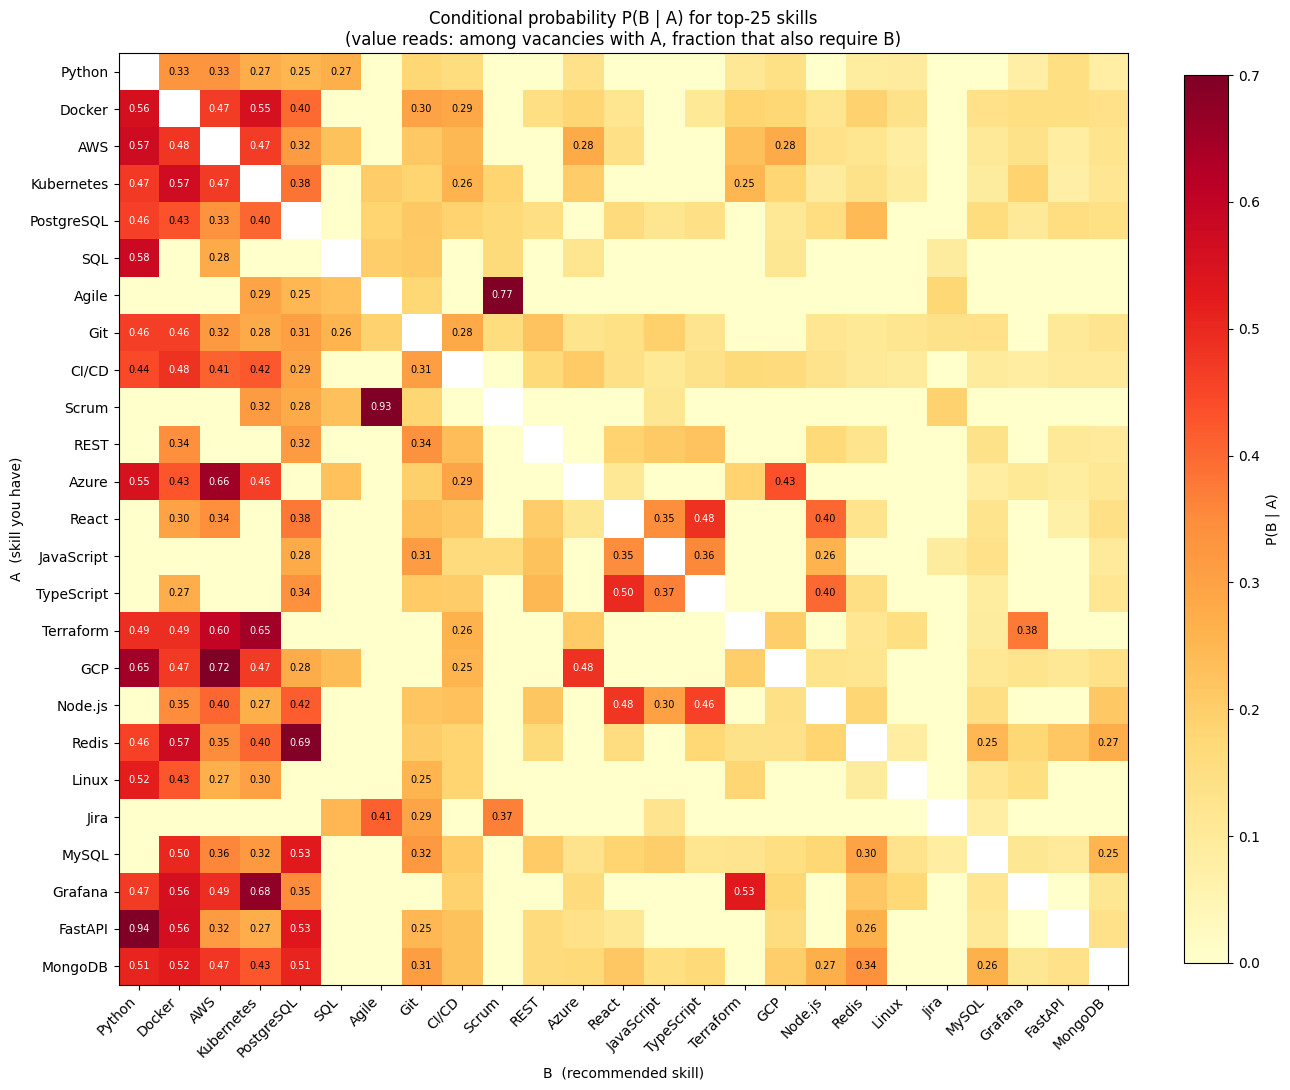

Saved: /kaggle/working/skillgap_heatmap.png


In [7]:
TOP_K = 25
top_skills = [s for s, _ in skill_freq.most_common(TOP_K)]

# Build a confidence matrix: row=A, col=B, value=P(B|A)
M = pd.DataFrame(0.0, index=top_skills, columns=top_skills)
for _, r in directed.iterrows():
    if r['from'] in top_skills and r['to'] in top_skills:
        M.loc[r['from'], r['to']] = r['confidence']
np.fill_diagonal(M.values, np.nan)

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(M.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.7)
ax.set_xticks(range(len(top_skills)))
ax.set_yticks(range(len(top_skills)))
ax.set_xticklabels(top_skills, rotation=45, ha='right')
ax.set_yticklabels(top_skills)
ax.set_xlabel('B  (recommended skill)')
ax.set_ylabel('A  (skill you have)')
ax.set_title('Conditional probability P(B | A) for top-25 skills\n(value reads: among vacancies with A, fraction that also require B)')
plt.colorbar(im, ax=ax, fraction=0.04, label='P(B | A)')

for i in range(len(top_skills)):
    for j in range(len(top_skills)):
        v = M.iloc[i, j]
        if not np.isnan(v) and v >= 0.25:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if v > 0.45 else 'black')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/skillgap_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/skillgap_heatmap.png')

## 8. Summary Block for the Report (Section 3.7)

In [8]:
print('=' * 60)
print('FOR THE REPORT (Section 3.7)')
print('=' * 60)
print(f'Sample size (vacancies with ≥2 skills): N = {N:,}')
print(f'Popular skills analyzed:                  {len(popular)}')
print(f'Skill pairs with support ≥ {MIN_SUPPORT*100:.1f}%:        {len(pairs):,}')
print()
print('Top 5 pairs by lift:')
for _, r in top_pairs.head(5).iterrows():
    print(f'  {r["A"]:<18} ↔  {r["B"]:<18}  lift = {r["lift"]:.2f},  support = {r["support_pct"]:.2f}%')

FOR THE REPORT (Section 3.7)
Sample size (vacancies with ≥2 skills): N = 19,472
Popular skills analyzed:                  203
Skill pairs with support ≥ 0.5%:        951

Top 5 pairs by lift:
  I2C                ↔  SPI                 lift = 116.46,  support = 0.72%
  I2C                ↔  UART                lift = 110.60,  support = 0.71%
  SPI                ↔  UART                lift = 109.95,  support = 0.72%
  LangChain          ↔  LlamaIndex          lift = 42.18,  support = 0.57%
  DNS                ↔  TCP/IP              lift = 39.08,  support = 0.55%
